In [3]:
#=======================================
#Imports
#========================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydriller
from pydriller import Repository
from datetime import datetime, timezone

# verify versions for reproducibility
print("Python   :", os.sys.executable)
print("pandas   :", pd.__version__)
print("pydriller:", pydriller.__version__)
print("seaborn  :", sns.__version__)

Python   : C:\Users\Hafsaa\numpy_analysis\venv\Scripts\python.exe
pandas   : 3.0.3
pydriller: 2.10
seaborn  : 0.13.2


In [4]:
#=======================================
#Repository path
#========================================
#we use os.path.join to make the path work on any OS
REPO_PATH = os.path.join(os.getcwd(), "numpy")

# make sure the repo exists and is a valid git folder
assert os.path.exists(REPO_PATH), f"Repository not found at: {REPO_PATH}"
assert os.path.exists(os.path.join(REPO_PATH, ".git")), \
    f"Not a git repository: {REPO_PATH}"

print("Repository found at:", REPO_PATH)

Repository found at: C:\Users\Hafsaa\numpy_analysis\numpy


In [5]:
#=======================================
#Pydriller test
#========================================
# quick test to check PyDriller can read the repo
test_commits = []

for commit in Repository(REPO_PATH, num_workers=1).traverse_commits():
    test_commits.append({
        "hash"   : commit.hash[:7],
        "author" : commit.author.name,
        "date"   : commit.author_date,
        "message": commit.msg[:60]
    })
    if len(test_commits) == 5:
        break

pd.DataFrame(test_commits)

,hash,author,date,message
0,f1a2d63,Eric Jones,2001-12-18 15:45:10+00:00,factored out the scipy specific distutils code...
1,74a4958,Eric Jones,2001-12-25 06:03:41+00:00,split scipy_test off into its own module.
2,a76efe8,Eric Jones,2001-12-25 06:05:32+00:00,added build_py module
3,76cfe83,Eric Jones,2001-12-25 06:06:40+00:00,added misc_util file that has a few routines u...
4,b1263a7,Eric Jones,2001-12-31 08:40:02+00:00,fixed path issues resulting from using setup_x...


In [6]:
#=======================================
#data extraction
#========================================
records = []

for commit in Repository(REPO_PATH, num_workers=1).traverse_commits():
    
    # skip merge commits as they double-count changes already in constituent commits
    if commit.merge:
        continue

    commit_hash  = commit.hash[:7]
    author       = commit.author.name
    author_email = commit.author.email
    date         = commit.author_date
    year_month   = date.strftime("%Y-%m")

    for file in commit.modified_files:

        # skip binary files
        if file.added_lines == 0 and file.deleted_lines == 0:
            continue

        # new_path is None for deleted files, old_path is None for added files
        file_path = file.new_path or file.old_path

        records.append({
            "commit_hash"  : commit_hash,
            "author"       : author,
            "author_email" : author_email,
            "date"         : date,
            "year_month"   : year_month,
            "file_path"    : file_path,
            "added_lines"  : file.added_lines,
            "deleted_lines": file.deleted_lines,
            "churn"        : file.added_lines + file.deleted_lines,
            "change_type"  : str(file.change_type)
        })

print(f"Extraction complete — {len(records):,} records")

KeyboardInterrupt: 

In [7]:
#=======================================
#Dataframe
#========================================
df = pd.DataFrame(records)

# convert date to pandas datetime
df["date"] = pd.to_datetime(df["date"], utc=True)

print("Shape:", df.shape)
print(df.dtypes)
df.head(3)

Shape: (35883, 10)
commit_hash                      str
author                           str
author_email                     str
date             datetime64[us, UTC]
year_month                       str
file_path                        str
added_lines                    int64
deleted_lines                  int64
churn                          int64
change_type                      str
dtype: object


,commit_hash,author,author_email,date,year_month,file_path,added_lines,deleted_lines,churn,change_type
0,f1a2d63,Eric Jones,eric@enthought.com,2001-12-18 15:45:10+00:00,2001-12,scipy_distutils\__init__.py,7,0,7,ModificationType.ADD
1,f1a2d63,Eric Jones,eric@enthought.com,2001-12-18 15:45:10+00:00,2001-12,scipy_distutils\command\__init__.py,29,0,29,ModificationType.ADD
2,f1a2d63,Eric Jones,eric@enthought.com,2001-12-18 15:45:10+00:00,2001-12,scipy_distutils\command\build.py,16,0,16,ModificationType.ADD


In [8]:
#=======================================
#Basic Inspection
#========================================
print(f"rows: {df.shape[0]:,} | columns: {df.shape[1]}")
print(f"date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"unique commits: {df['commit_hash'].nunique():,} | authors: {df['author'].nunique():,} | files: {df['file_path'].nunique():,}")
print("\nmissing values:")
print(df.isnull().sum())
print("\nchange types:")
print(df['change_type'].value_counts())
print("\nchurn stats:")
print(df['churn'].describe())

rows: 35,883 | columns: 10
date range: 2001-12-18 → 2017-09-25
unique commits: 13,837 | authors: 680 | files: 3,359

missing values:
commit_hash      0
author           0
author_email     0
date             0
year_month       0
file_path        0
added_lines      0
deleted_lines    0
churn            0
change_type      0
dtype: int64

change types:
change_type
ModificationType.MODIFY    31334
ModificationType.DELETE     2370
ModificationType.ADD        2040
ModificationType.RENAME      139
Name: count, dtype: int64

churn stats:
count    35883.000000
mean       109.997548
std       1307.219173
min          1.000000
25%          3.000000
50%         10.000000
75%         36.000000
max      97895.000000
Name: churn, dtype: float64


In [9]:
#=======================================
#Outlier Inspection
#========================================
# check top 20 highest churn records before cleaning
df.nlargest(20, "churn")[["commit_hash", "date", "file_path", "added_lines", "deleted_lines", "churn", "change_type"]]

,commit_hash,date,file_path,added_lines,deleted_lines,churn,change_type
26126,c679f7b,2012-10-17 14:02:32+00:00,numpy\core\src\umath\lapack_lite\dlapack_lite.c,97895,0,97895,ModificationType.ADD
34068,7189824,2017-03-02 22:05:05+00:00,numpy\linalg\lapack_lite\dlapack_lite.c,0,96068,96068,ModificationType.DELETE
33667,224abf8,2016-12-14 01:16:40+00:00,numpy\linalg\lapack_lite\dlapack_lite.c,77773,17703,95476,ModificationType.MODIFY
33661,35ea1c9,2016-12-13 19:41:52+00:00,numpy\linalg\lapack_lite\dlapack_lite.c,10094,74937,85031,ModificationType.MODIFY
34071,7189824,2017-03-02 22:05:05+00:00,numpy\linalg\lapack_lite\f2c_d_lapack.c,36180,0,36180,ModificationType.ADD
26240,9c00887,2013-04-10 16:35:13+00:00,numpy\linalg\dlapack_lite.c,0,36008,36008,ModificationType.DELETE
2861,4bea674,2005-09-14 23:58:12+00:00,scipy\corelib\lapack_lite\dlapack_lite.c,36005,0,36005,ModificationType.ADD
8232,6782a92,2006-07-06 16:57:20+00:00,numpy\linalg\dlapack_lite.c,0,36005,36005,ModificationType.DELETE
11793,e76b5fa,2007-12-15 18:54:52+00:00,numpy\linalg\dlapack_lite.c,0,36005,36005,ModificationType.DELETE
34073,7189824,2017-03-02 22:05:05+00:00,numpy\linalg\lapack_lite\f2c_s_lapack.c,34925,0,34925,ModificationType.ADD


In [10]:
#=======================================
#Data cleaning
#========================================
print(f"records before cleaning: {len(df):,}")

# clean up change_type labels
df["change_type"] = df["change_type"].str.replace("ModificationType.", "", regex=False)

# extract file extension and top-level directory
df["extension"] = df["file_path"].apply(
    lambda p: os.path.splitext(p)[-1].lower() if p else ""
)
df["top_dir"] = df["file_path"].apply(
    lambda p: p.replace("\\", "/").split("/")[0] if p else ""
)

# remove auto-generated and vendored files
vendored_keywords = ["lapack_lite", "f2c_", "mtrand.c", "numpybook", ".lyx"]
mask_vendored = df["file_path"].apply(
    lambda p: any(kw in str(p) for kw in vendored_keywords)
)
df_clean = df[~mask_vendored].copy()

print(f"records removed: {mask_vendored.sum():,}")
print(f"records after cleaning: {len(df_clean):,}")
print("\ntop 15 extensions:")
print(df_clean["extension"].value_counts().head(15))

records before cleaning: 35,883
records removed: 411
records after cleaning: 35,472

top 15 extensions:
extension
.py      20170
.c        5746
.h        2387
.src      1998
.rst      1886
.txt       840
           640
.cc        228
.pyx       206
.f         182
.html      160
.in        124
.i         111
.sh         78
.yml        75
Name: count, dtype: int64


In [11]:
#=======================================
#File categorization
#========================================
source_extensions = {".py", ".c", ".h", ".pyx", ".pxd", ".cpp"}
template_extensions = {".src"}
doc_extensions = {".rst", ".txt"}
config_extensions = {".yml", ".yaml", ".toml", ".cfg", ".ini", ".build", ".in", ".sh"}

def categorize(ext):
    if ext in source_extensions:   return "source"
    if ext in template_extensions: return "template"
    if ext in doc_extensions:      return "documentation"
    if ext in config_extensions:   return "config"
    return "other"

df_clean["file_category"] = df_clean["extension"].apply(categorize)

print(df_clean["file_category"].value_counts())

# save full clean dataset and source-only subset
os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/numpy_file_changes_clean.csv", index=False)

df_source = df_clean[df_clean["file_category"] == "source"].copy()
df_source.to_csv("data/numpy_source_changes.csv", index=False)

print(f"\nsource records: {len(df_source):,}")

file_category
source           28590
documentation     2726
template          1998
other             1859
config             299
Name: count, dtype: int64

source records: 28,590


In [12]:
#=======================================
#Component aggregation
#========================================
# extract second-level path as the component
def extract_component(path):
    parts = str(path).replace("\\", "/").split("/")
    return parts[0] + "/" + parts[1] if len(parts) >= 2 else parts[0]

df_source["component"] = df_source["file_path"].apply(extract_component)

component_counts = (
    df_source.groupby("component")
    .agg(
        modifications  = ("commit_hash", "count"),
        total_churn    = ("churn", "sum"),
        total_added    = ("added_lines", "sum"),
        total_deleted  = ("deleted_lines", "sum"),
        unique_files   = ("file_path", "nunique"),
        unique_commits = ("commit_hash", "nunique")
    )
    .sort_values("total_churn", ascending=False)
    .reset_index()
)

component_counts.head(20)

,component,modifications,total_churn,total_added,total_deleted,unique_files,unique_commits
0,numpy/core,11372,630502,336589,293913,343,5420
1,numpy/f2py,1373,149882,50498,99384,138,370
2,weave/blitz-20001213,357,98818,49409,49409,131,5
3,numpy/lib,2948,97895,62239,35656,65,1582
4,scipy/weave,368,81755,9793,71962,212,10
5,scipy/base,1180,58351,39619,18732,66,487
6,numpy/linalg,443,51147,7930,43217,17,321
7,numpy/ma,1127,49008,29851,19157,21,588
8,numpy/distutils,1931,42735,18936,23799,90,971
9,numpy/numarray,313,39089,13487,25602,40,122


In [13]:
# filter out historical artifacts (early scipy namespace, deprecated weave)
historical_prefixes = ["scipy/", "weave/", "_randomgen/"]

component_counts["is_historical"] = component_counts["component"].apply(
    lambda c: any(c.startswith(p) for p in historical_prefixes)
)

df_active = component_counts[~component_counts["is_historical"]].copy()
df_top15  = df_active.head(15).copy()

print(f"active components: {len(df_active)} | historical filtered: {component_counts['is_historical'].sum()}")
df_top15[["component", "modifications", "total_churn", "unique_files", "unique_commits"]]

active components: 286 | historical filtered: 79


,component,modifications,total_churn,unique_files,unique_commits
0,numpy/core,11372,630502,343,5420
1,numpy/f2py,1373,149882,138,370
3,numpy/lib,2948,97895,65,1582
6,numpy/linalg,443,51147,17,321
7,numpy/ma,1127,49008,21,588
8,numpy/distutils,1931,42735,90,971
9,numpy/numarray,313,39089,40,122
10,numpy/polynomial,610,37538,20,176
11,numpy/testing,567,24317,22,378
12,numpy/doc,365,24192,75,153


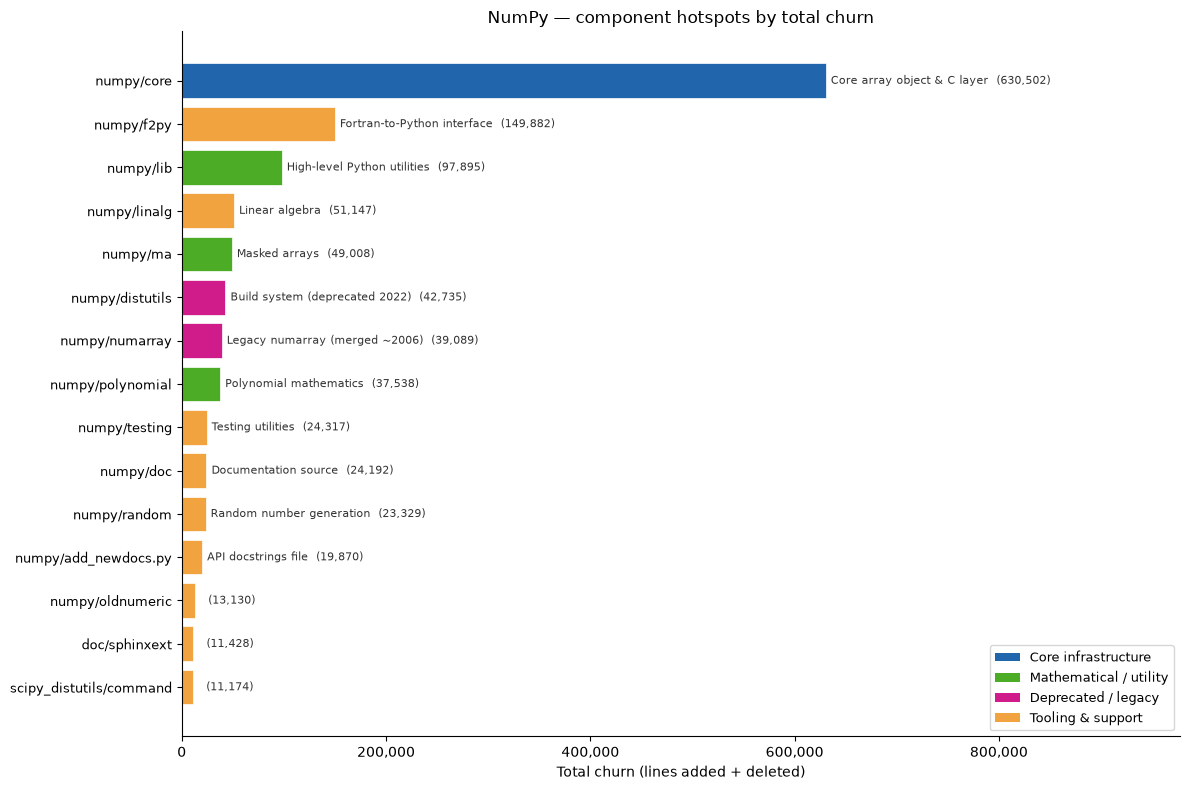

In [14]:
#=======================================
#Component hotspot barchart
#========================================
from matplotlib.patches import Patch

descriptions = {
    "numpy/core"          : "Core array object & C layer",
    "numpy/_core"         : "Core (post-2.0 reorganization)",
    "numpy/f2py"          : "Fortran-to-Python interface",
    "numpy/lib"           : "High-level Python utilities",
    "numpy/random"        : "Random number generation",
    "numpy/distutils"     : "Build system (deprecated 2022)",
    "numpy/linalg"        : "Linear algebra",
    "numpy/ma"            : "Masked arrays",
    "numpy/polynomial"    : "Polynomial mathematics",
    "numpy/testing"       : "Testing utilities",
    "numpy/numarray"      : "Legacy numarray (merged ~2006)",
    "numpy/doc"           : "Documentation source",
    "numpy/typing"        : "Type annotations (post-2020)",
    "numpy/add_newdocs.py": "API docstrings file",
    "numpy/fft"           : "Fourier transforms",
}

colors = [
    "#2166ac" if "core" in c else
    "#4dac26" if c in ["numpy/lib", "numpy/ma", "numpy/polynomial", "numpy/fft"] else
    "#d01c8b" if c in ["numpy/distutils", "numpy/numarray"] else
    "#f1a340"
    for c in df_top15.sort_values("total_churn", ascending=True)["component"]
]

df_plot = df_top15.sort_values("total_churn", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(df_plot["component"], df_plot["total_churn"],
               color=colors, edgecolor="white", linewidth=0.5)

for bar, (_, row) in zip(bars, df_plot.iterrows()):
    desc = descriptions.get(row["component"], "")
    ax.text(bar.get_width() + 5000,
            bar.get_y() + bar.get_height() / 2,
            f"{desc}  ({row['total_churn']:,})",
            va="center", ha="left", fontsize=8, color="#333333")

ax.set_xlabel("Total churn (lines added + deleted)")
ax.set_title("NumPy — component hotspots by total churn")
ax.set_xlim(0, df_plot["total_churn"].max() * 1.55)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

legend_elements = [
    Patch(facecolor="#2166ac", label="Core infrastructure"),
    Patch(facecolor="#4dac26", label="Mathematical / utility"),
    Patch(facecolor="#d01c8b", label="Deprecated / legacy"),
    Patch(facecolor="#f1a340", label="Tooling & support"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/01_component_hotspots.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
#=======================================
#Data preparation for Monthly churn time series
#========================================
# numpy/_core is excluded as it's same component as numpy/core, just renamed in 2.0
top6 = ["numpy/core", "numpy/f2py", "numpy/lib", "numpy/random", "numpy/distutils", "numpy/linalg"]

monthly = (
    df_source[df_source["component"].isin(top6)]
    .groupby(["year_month", "component"])["churn"]
    .sum()
    .reset_index()
)

monthly["date"] = pd.to_datetime(monthly["year_month"] + "-01", utc=True)
monthly = monthly.sort_values(["component", "date"])

# 3-month rolling average to smooth monthly spikes
monthly["churn_smooth"] = (
    monthly.groupby("component")["churn"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

print(f"date range: {monthly['date'].min().strftime('%Y-%m')} → {monthly['date'].max().strftime('%Y-%m')}")
monthly.head(8)

date range: 2006-01 → 2017-09


,year_month,component,churn,date,churn_smooth
0,2006-01,numpy/core,5681,2006-01-01 00:00:00+00:00,5681.000000
6,2006-02,numpy/core,7575,2006-02-01 00:00:00+00:00,6628.000000
12,2006-03,numpy/core,4357,2006-03-01 00:00:00+00:00,5871.000000
18,2006-04,numpy/core,2242,2006-04-01 00:00:00+00:00,4724.666667
23,2006-05,numpy/core,973,2006-05-01 00:00:00+00:00,2524.000000
29,2006-06,numpy/core,8784,2006-06-01 00:00:00+00:00,3999.666667
35,2006-07,numpy/core,55556,2006-07-01 00:00:00+00:00,21771.000000
41,2006-08,numpy/core,11217,2006-08-01 00:00:00+00:00,25185.666667


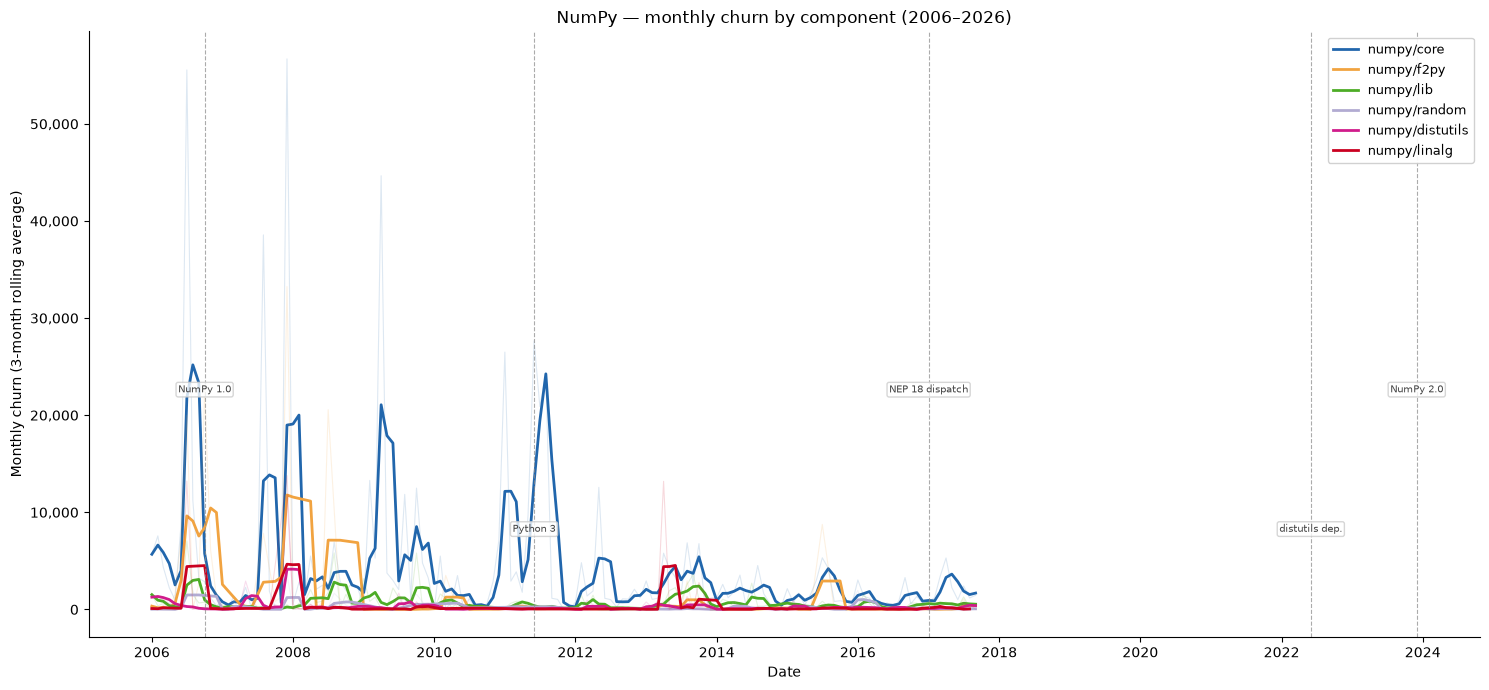

In [16]:
#=======================================
#Time series plot
#========================================
component_colors = {
    "numpy/core"     : "#2166ac",
    "numpy/f2py"     : "#f1a340",
    "numpy/lib"      : "#4dac26",
    "numpy/random"   : "#b2abd2",
    "numpy/distutils": "#d01c8b",
    "numpy/linalg"   : "#ca0020",
}

events = [
    ("2006-10", "NumPy 1.0",       "top"),
    ("2011-06", "Python 3",        "bottom"),
    ("2017-01", "NEP 18 dispatch", "top"),
    ("2022-06", "distutils dep.",  "bottom"),
    ("2023-12", "NumPy 2.0",       "top"),
]

fig, ax = plt.subplots(figsize=(15, 7))

for comp in top6:
    subset = monthly[monthly["component"] == comp]
    ax.plot(subset["date"], subset["churn"],
            color=component_colors[comp], alpha=0.15, linewidth=0.8)
    ax.plot(subset["date"], subset["churn_smooth"],
            color=component_colors[comp], linewidth=2, label=comp)

y_max = monthly["churn_smooth"].max()

for event_date, label, position in events:
    x = pd.to_datetime(event_date + "-01", utc=True)
    ax.axvline(x=x, color="#888888", linestyle="--", linewidth=0.8, alpha=0.7)
    y_pos = y_max * 0.92 if position == "top" else y_max * 0.35
    ax.text(x, y_pos, label, fontsize=7.5, color="#444444",
            ha="center", va="top",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

ax.set_xlabel("Date")
ax.set_ylabel("Monthly churn (3-month rolling average)")
ax.set_title("NumPy — monthly churn by component (2006–2026)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper right", fontsize=9, framealpha=0.9, edgecolor="#cccccc")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plots/02_component_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
#=======================================
#Heatmap data preparation
#========================================
# exclude numpy/_core again as it's same component as numpy/core, renamed in 2.0
top12 = [c for c in df_active.head(13)["component"].tolist() if c != "numpy/_core"][:12]

df_source["year"] = df_source["date"].dt.year

heatmap_data = (
    df_source[df_source["component"].isin(top12)]
    .groupby(["year", "component"])["churn"]
    .sum()
    .reset_index()
)

heatmap_pivot = heatmap_data.pivot(
    index="component", columns="year", values="churn"
).fillna(0)

heatmap_pivot = heatmap_pivot.loc[
    heatmap_pivot.sum(axis=1).sort_values(ascending=False).index
]

# normalize each row by its own max to show relative activity per component
heatmap_normalized = heatmap_pivot.div(heatmap_pivot.max(axis=1), axis=0)

print(heatmap_normalized.shape)

(12, 12)


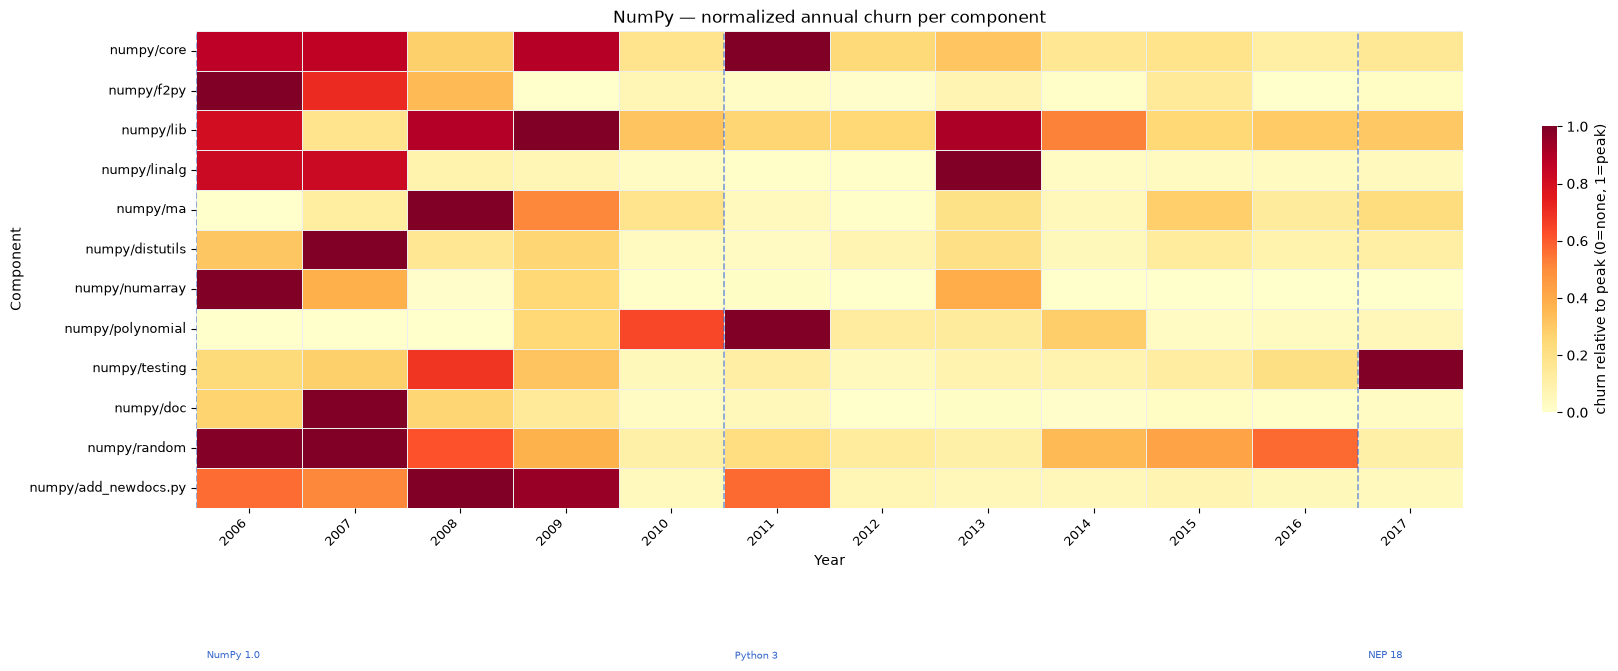

In [18]:
#=======================================
#Heatmap
#========================================
fig, ax = plt.subplots(figsize=(18, 7))

sns.heatmap(
    heatmap_normalized, ax=ax,
    cmap="YlOrRd", linewidths=0.4, linecolor="#eeeeee",
    vmin=0, vmax=1, annot=False,
    cbar_kws={"label": "churn relative to peak (0=none, 1=peak)", "shrink": 0.6}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

event_years = {
    2006: "NumPy 1.0",
    2011: "Python 3",
    2017: "NEP 18",
    2019: "random rewrite",
    2022: "distutils dep.",
    2024: "NumPy 2.0",
}

years = list(heatmap_normalized.columns)
for year, label in event_years.items():
    if year in years:
        x_pos = years.index(year)
        ax.axvline(x=x_pos, color="#3366cc", linewidth=1.2, linestyle="--", alpha=0.6)
        ax.text(x_pos + 0.1, -0.3, label, fontsize=7, color="#3366cc",
                ha="left", va="top", transform=ax.get_xaxis_transform())

ax.set_title("NumPy — normalized annual churn per component")
ax.set_xlabel("Year")
ax.set_ylabel("Component")

plt.tight_layout()
plt.savefig("plots/03_component_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
#=======================================
#File-level hotspot analysis
#========================================
file_level = (
    df_source.groupby("file_path")
    .agg(
        modifications  = ("commit_hash", "count"),
        total_churn    = ("churn", "sum"),
        total_added    = ("added_lines", "sum"),
        total_deleted  = ("deleted_lines", "sum"),
        unique_commits = ("commit_hash", "nunique"),
        first_seen     = ("date", "min"),
        last_seen      = ("date", "max"),
    )
    .reset_index()
)

file_level["lifespan_years"] = (
    (file_level["last_seen"] - file_level["first_seen"]).dt.days / 365.25
).round(1)

# churn per year — normalizes for file age
file_level["churn_density"] = (
    file_level["total_churn"] / file_level["lifespan_years"].clip(lower=0.5)
).round(1)

file_level_sorted = file_level.sort_values("modifications", ascending=False).reset_index(drop=True)

file_level_sorted[["file_path", "modifications", "total_churn", "lifespan_years", "churn_density"]].head(20)

,file_path,modifications,total_churn,lifespan_years,churn_density
0,numpy\core\tests\test_multiarray.py,474,16044,11.7,1371.3
1,numpy\core\src\arrayobject.c,436,92063,3.3,27897.9
2,numpy\lib\function_base.py,411,16192,11.6,1395.9
3,numpy\core\setup.py,387,5045,11.6,434.9
4,numpy\ma\core.py,384,18749,9.8,1913.2
5,numpy\core\tests\test_regression.py,381,7122,11.1,641.6
6,numpy\core\src\umath\ufunc_object.c,323,26505,8.3,3193.4
7,numpy\core\src\multiarraymodule.c,321,45152,3.3,13682.4
8,numpy\core\numeric.py,315,9788,11.7,836.6
9,numpy\core\src\multiarray\multiarraymodule.c,302,10115,8.4,1204.2


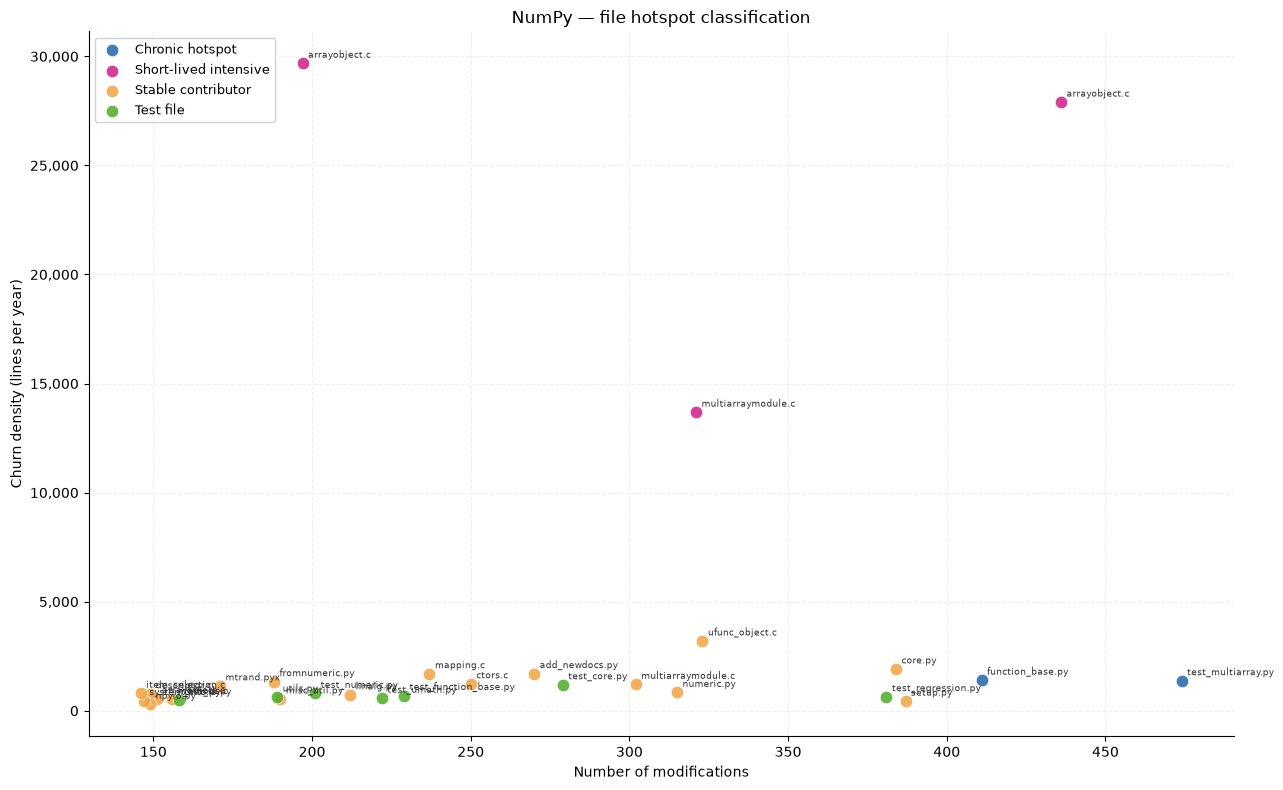

In [20]:
#=======================================
#File hotspot scatter plot
#========================================
df_scatter = file_level_sorted.head(30).copy()
df_scatter["label"] = df_scatter["file_path"].apply(
    lambda p: p.replace("\\", "/").split("/")[-1]
)

def classify_file(row):
    if row["lifespan_years"] < 5:        return "Short-lived intensive"
    if row["modifications"] > 400 and row["churn_density"] > 800: return "Chronic hotspot"
    if "test" in row["file_path"].lower(): return "Test file"
    return "Stable contributor"

df_scatter["category"] = df_scatter.apply(classify_file, axis=1)

cat_colors = {
    "Short-lived intensive": "#d01c8b",
    "Chronic hotspot"      : "#2166ac",
    "Test file"            : "#4dac26",
    "Stable contributor"   : "#f1a340",
}

fig, ax = plt.subplots(figsize=(13, 8))

for cat, group in df_scatter.groupby("category"):
    ax.scatter(group["modifications"], group["churn_density"],
               c=cat_colors[cat], label=cat, s=80, alpha=0.85,
               edgecolors="white", linewidth=0.5, zorder=3)

for _, row in df_scatter.iterrows():
    ax.annotate(row["label"],
                xy=(row["modifications"], row["churn_density"]),
                xytext=(4, 4), textcoords="offset points",
                fontsize=6.5, color="#333333")

ax.set_xlabel("Number of modifications")
ax.set_ylabel("Churn density (lines per year)")
ax.set_title("NumPy — file hotspot classification")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9, framealpha=0.9, edgecolor="#cccccc")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("plots/04_file_hotspot_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
#=======================================
#Save file-level results
#========================================
file_level_sorted.to_csv("data/numpy_file_hotspots.csv", index=False)
print(f"files tracked: {len(file_level_sorted):,}")

files tracked: 2,088
